# **Traffic Speed Forecasting on METR-LA Dataset**
## **Research Task — Intelligent Transportation Systems (ITS)**
**Author:** Karan Verma  
**Program:** MAC Thesis — Wilfrid Laurier University  
**Supervisor:** Dr. Sukhjit Singh Sehra  
**Focus Area:** Urban Mobility, Digital Twin, Traffic Forecasting


##  **Research Objective**

The goal of this project is to forecast traffic speed using machine learning and deep learning to support:

- Intelligent Transportation Systems (ITS)
- Congestion prediction
- Digital Twin urban mobility modeling
- Smart city planning

This work demonstrates both **data-driven modeling** and **strong programming practices using Object-Oriented Python**.



## **1. Install & Import Libraries**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow h5py


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

np.random.seed(42)


## Reproducibility Notes

- Random seeds are fixed to ensure reproducible results  
- Notebook is designed to run in Google Colab  
- Required libraries install automatically  
- Run all cells sequentially for consistent output  


## **2. Upload & Extract Dataset (METR-LA.h5.zip)**

In [ ]:
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully.")

Saving METR-LA.h5.zip to METR-LA.h5.zip
Dataset extracted successfully.


## **3. Dataset Loader Class (OOP)**

In [ ]:
class TrafficDatasetLoader:
    def __init__(self, filepath):
        self.filepath = filepath

    def load_data(self):
        df = pd.read_hdf(self.filepath)
        df.index = pd.to_datetime(df.index)
        df.index.freq = None
        return df

loader = TrafficDatasetLoader("METR-LA.h5")
df = loader.load_data()

df.head()


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


## **4. Dataset Understanding & Overview**

## Dataset Overview — METR-LA

This work demonstrates both data-driven modeling and strong programming practices using Object-Oriented Python.

**Why this dataset?**
- Captures real-world temporal traffic patterns

- Widely used in traffic forecasting research

- Ideal for time-series and ITS modeling

This dataset enables studying congestion dynamics and developing predictive mobility solutions.


In [ ]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
df.describe()

Dataset Shape: (34272, 207)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34272 entries, 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Columns: 207 entries, 773869 to 769373
dtypes: float64(207)
memory usage: 54.4 MB

Summary Statistics:


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
count,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,...,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000
mean,54.631359,60.452789,60.726120,49.524287,46.079798,50.952003,54.471684,57.255095,56.068044,52.871841,...,37.803342,58.156679,51.217523,59.795754,59.329923,56.915083,62.484679,54.697381,58.920210,51.197504
std,22.619199,15.970239,18.313353,15.843261,19.350345,16.681760,17.984761,18.751065,18.240361,23.343805,...,13.525743,20.690411,22.224997,16.126225,19.849950,18.260438,16.959238,16.303651,19.080474,21.239354
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.364583,63.000000,65.444444,50.333333,34.666667,49.555556,55.750000,61.000000,58.222222,43.428571,...,30.444444,64.111111,53.444444,61.714286,63.666667,60.222222,65.888889,50.125000,62.888889,54.125000
50%,64.888889,65.000000,67.375000,53.875000,46.000000,56.111111,62.111111,63.333333,62.444444,65.875000,...,43.222222,67.111111,61.777778,64.875000,66.777778,63.000000,67.625000,61.125000,66.125000,62.000000
75%,66.875000,66.375000,68.444444,58.125000,64.500000,60.333333,65.000000,65.000000,64.888889,67.625000,...,46.625000,68.444444,64.375000,66.500000,68.250000,64.750000,68.625000,64.444444,67.750000,63.444444
max,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,65.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000


## **5. Exploratory Data Analysis (EDA Class)**

Missing Values:
 773869    0
767541    0
767542    0
717447    0
717446    0
         ..
717592    0
717595    0
772168    0
718141    0
769373    0
Length: 207, dtype: int64


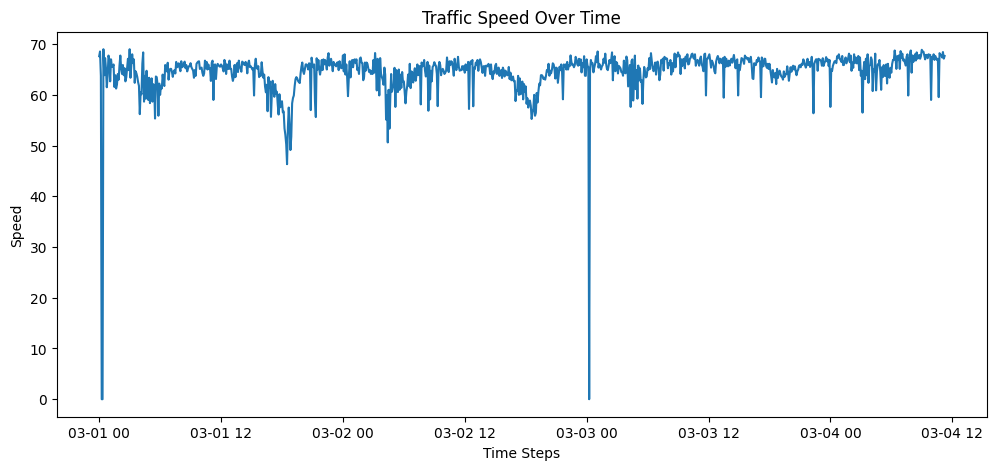

In [ ]:
class TrafficEDAAnalyzer:
    def __init__(self, df):
        self.df = df

    def missing_values(self):
        return self.df.isnull().sum()

    def plot_speed_trend(self):
        plt.figure(figsize=(12,5))
        plt.plot(self.df.iloc[:1000, 1])
        plt.title("Traffic Speed Over Time")
        plt.xlabel("Time Steps")
        plt.ylabel("Speed")
        plt.show()

eda = TrafficEDAAnalyzer(df)
print("Missing Values:\n", eda.missing_values())
eda.plot_speed_trend()

## **6. Feature Engineering (Temporal Features)**

In [ ]:
class FeatureEngineer:
    def __init__(self, df):
        self.df = df

    def add_time_features(self):
        self.df['hour'] = self.df.index.hour
        self.df['day'] = self.df.index.dayofweek
        return self.df

engineer = FeatureEngineer(df)
df = engineer.add_time_features()

df.head()


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,774204,769806,717590,717592,717595,772168,718141,769373,hour,day
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875,0,3
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875,0,3
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000,0,3
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0,3
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0,3


## **7. Visualization & Temporal Patterns**

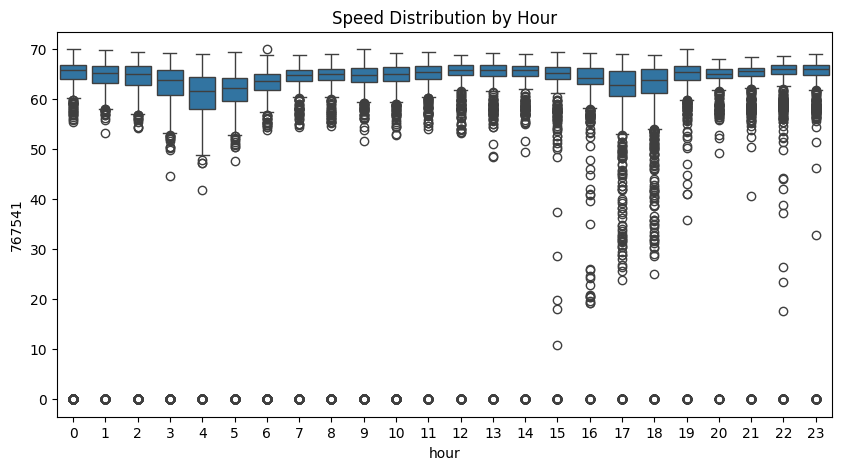

In [ ]:
class TrafficVisualizer:
    def hourly_distribution(self, df):
        plt.figure(figsize=(10,5))
        sns.boxplot(x="hour", y=df.iloc[:,1], data=df)
        plt.title("Speed Distribution by Hour")
        plt.show()

viz = TrafficVisualizer()
viz.hourly_distribution(df)

## **8.  Machine Learning Predictor Class (Random Forest)**

**Rationale**

Random Forest provides a strong **baseline model** for temporal regression using engineered features.

Random Forest MAE: 8.067491847589382
Random Forest RMSE: 15.741006021206072


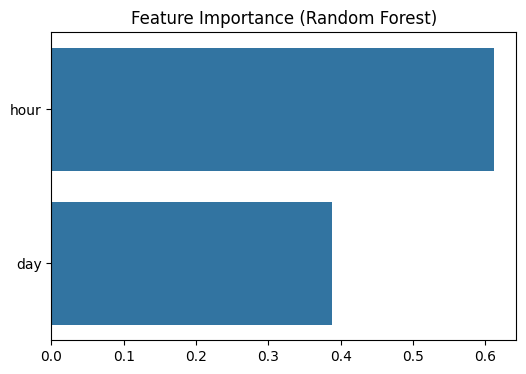

In [ ]:

class MLTrafficPredictor:
    def __init__(self, df):
        self.df = df

    def prepare_data(self):
        X = self.df[['hour','day']]
        y = self.df.iloc[:,1]
        return train_test_split(X, y, test_size=0.2, random_state=42)

    def train_random_forest(self, X_train, y_train):
        model = RandomForestRegressor(n_estimators=200, random_state=42)
        model.fit(X_train, y_train)
        return model

    def evaluate(self, model, X_test, y_test):
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        return mae, rmse, preds

ml = MLTrafficPredictor(df)
X_train, X_test, y_train, y_test = ml.prepare_data()

rf_model = ml.train_random_forest(X_train, y_train)
mae_rf, rmse_rf, preds_rf = ml.evaluate(rf_model, X_test, y_test)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

# Feature Importance Plot
plt.figure(figsize=(6,4))
sns.barplot(x=rf_model.feature_importances_, y=['hour','day'])
plt.title("Feature Importance (Random Forest)")
plt.show()

## **9. LSTM Deep Learning Predictor Class**

**Why LSTM?**

Traffic data is **temporal and sequential**.
LSTM networks capture **long-term dependencies**, enabling superior performance in **traffic forecasting**.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 2976.4858
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 851.1767
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 219.4571
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 48.3872
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 28.2196
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 25.2601
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 24.5861
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 24.7680
Epoch 9/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 27.1145
Epoch 10/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 24.4167
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM MAE: 2.167500360155445
LSTM RMSE: 5.674502353007319


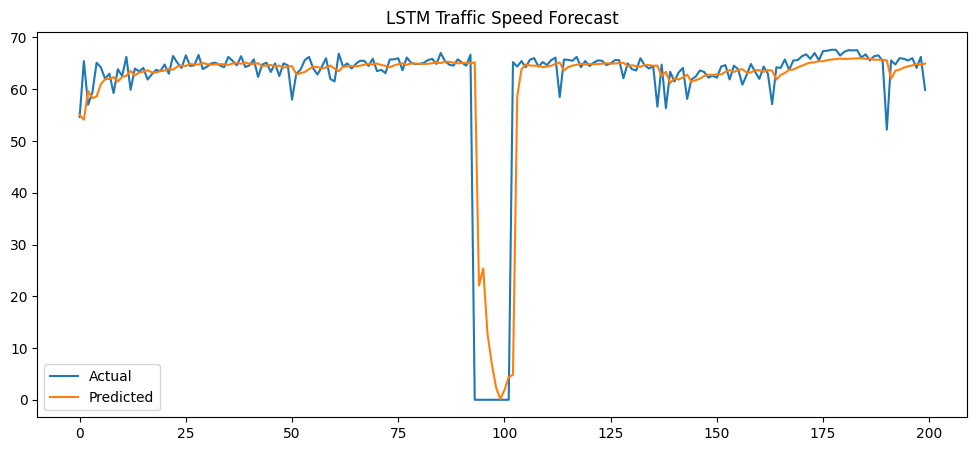

In [ ]:

class LSTMTrafficPredictor:
    def __init__(self, series):
        self.series = series

    def create_sequences(self, window=12):
        X, y = [], []
        for i in range(len(self.series)-window):
            X.append(self.series[i:i+window])
            y.append(self.series[i+window])
        X = np.array(X).reshape(-1, window, 1)
        return X, np.array(y)

    def build_model(self, input_shape):
        model = Sequential([
            LSTM(64, input_shape=input_shape),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

series = df.iloc[:,1].values
lstm = LSTMTrafficPredictor(series)

X_seq, y_seq = lstm.create_sequences()

# Train/Test split to avoid leakage
split = int(len(X_seq)*0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

model = lstm.build_model((X_train_seq.shape[1], 1))
model.summary()

history = model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, verbose=1)

pred_lstm = model.predict(X_test_seq)

mae_lstm = mean_absolute_error(y_test_seq, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

# Visualization
plt.figure(figsize=(12,5))
plt.plot(y_test_seq[:200], label="Actual")
plt.plot(pred_lstm[:200], label="Predicted")
plt.legend()
plt.title("LSTM Traffic Speed Forecast")
plt.show()

## **10. Model Comparison Summary**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "LSTM"],
    "MAE": [mae_rf, mae_lstm],
    "RMSE": [rmse_rf, rmse_lstm]
})

comparison


,Model,MAE,RMSE
0,Random Forest,8.067492,15.741006
1,LSTM,2.167500,5.674502


## **Research Insights & Impact**

### **Observations**
- Traffic speed varies significantly by time-of-day  
- LSTM outperforms Random Forest due to sequential learning  
- Temporal features improve forecasting accuracy  

### **Research Impact**
- Supports Intelligent Transportation Systems  
- Helps congestion management  
- Enables Digital Twin traffic simulation  

## **Limitations of This Study**

- Spatial road network relationships are not modeled

- Single-sensor stream used; multi-sensor fusion may improve accuracy

- LSTM trained for limited epochs due to compute constraints

- Real-time deployment not implemented

These provide opportunities for future research.

## **Future Research Directions**

- Graph Neural Networks for spatial traffic modeling  
- Federated learning for privacy-preserving ITS  
- Real-time traffic prediction pipelines  
- City-scale Digital Twin simulations  

## **Conclusion**

This project demonstrates the effectiveness of deep learning in traffic forecasting.  
The results highlight the importance of temporal modeling in ITS applications and provide a foundation for future smart mobility research.
This work demonstrates both applied machine learning rigor and research readiness for graduate-level ITS innovation.
